In [1]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Found cached dataset csv (C:/Users/theim/.cache/huggingface/datasets/lukebarousse___csv/lukebarousse--data_jobs-20095235c13fb98d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1)


  0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
# Filter for only US jobs
df_US = df[
    (df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')
].copy()

In [15]:
# Create job posted month number column
df_US['job_posted_month_no'] = df_US['job_posted_date'].dt.month

In [26]:
# explode the job_skills column and pivot
df_US_exploded =df_US.explode('job_skills')
df_US_pivot = df_US_exploded.pivot_table(
    index='job_posted_month_no',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
)

In [27]:
# sort the skills by count
df_US_pivot.loc['Total'] = df_US_pivot.sum()
df_US_pivot = df_US_pivot[df_US_pivot.loc['Total'].sort_values(ascending=False).index]
df_US_pivot = df_US_pivot.drop('Total')

In [28]:
# Use month names for plotting
df_US_pivot = df_US_pivot.reset_index()
df_US_pivot['job_posted_month'] = df_US_pivot['job_posted_month_no'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b')
)
df_US_pivot = df_US_pivot.set_index('job_posted_month')
df_US_pivot = df_US_pivot.drop(columns='job_posted_month_no')

In [29]:
df_US_pivot

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,google chat,openstack,theano,asp.net core,qt,couchdb,capacitor,codecommit,chainer,msaccess
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,4601,3592,2488,2254,1832,1513,1337,968,972,718,...,0,0,0,0,0,0,1,1,0,0
Feb,3168,2587,1676,1618,1212,1045,1122,738,705,514,...,0,0,0,0,0,0,0,0,0,0
Mar,3226,2661,1804,1683,1238,1141,1054,736,669,418,...,1,0,0,0,0,0,0,0,0,0
Apr,3220,2549,1789,1679,1302,1038,1057,695,650,439,...,0,0,0,0,0,1,0,0,0,0
May,2581,2118,1432,1349,972,867,860,557,515,358,...,0,0,0,0,0,0,0,0,0,1
Jun,2862,2382,1628,1609,984,1017,989,721,624,414,...,0,1,0,0,1,0,0,0,0,0
Jul,2609,2118,1533,1438,996,881,881,587,549,401,...,0,0,0,0,0,0,0,0,0,0
Aug,3414,2731,1951,2025,1276,1271,1208,752,746,484,...,0,0,0,0,0,0,0,0,0,0
Sep,2295,1801,1353,1229,856,746,820,478,475,359,...,0,0,0,0,0,0,0,0,0,0


In [30]:
# Create job posted month number column
df_US['job_posted_month_no'] = df_US['job_posted_date'].dt.month

# Get total number of job postings per month (important!)
monthly_totals = df_US.groupby('job_posted_month_no').size()

# Explode and create the pivot of skill counts
df_US_exploded = df_US.explode('job_skills')

df_US_pivot = df_US_exploded.pivot_table(
    index='job_posted_month_no',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
)

# Convert counts → percentage of jobs that month
df_US_pivot = df_US_pivot.div(monthly_totals, axis=0) * 100

# Sort the skills by total demand (using the percentage totals)
df_US_pivot.loc['Total'] = df_US_pivot.sum()
df_US_pivot = df_US_pivot[df_US_pivot.loc['Total'].sort_values(ascending=False).index]
df_US_pivot = df_US_pivot.drop('Total')

# Use month names for plotting
df_US_pivot = df_US_pivot.reset_index()
df_US_pivot['job_posted_month'] = df_US_pivot['job_posted_month_no'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b')
)
df_US_pivot = df_US_pivot.set_index('job_posted_month')
df_US_pivot = df_US_pivot.drop(columns='job_posted_month_no')

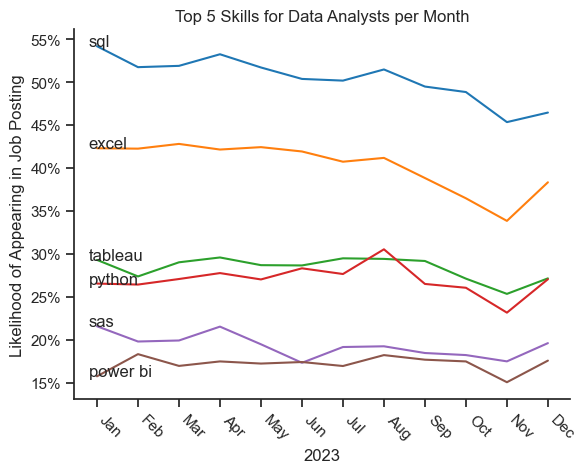

In [60]:
df_plot = df_US_pivot.iloc[:, :6]

sns.set_theme(style='ticks')

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.despine()

plt.title('Top 5 Skills for Data Analysts per Month')
plt.xticks(rotation=-45, ha='left')
plt.xlabel('2023')
plt.ylabel('Likelihood of Appearing in Job Posting')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(6):
    plt.text(-0.2, df_plot.iloc[0, i], df_plot.columns[i])

plt.show()

In [24]:
df_US_pivot

job_skills,sql,excel,tableau,python,sas,power bi,r,word,powerpoint,oracle,...,asp.net core,openstack,qt,kotlin,couchdb,ionic,google chat,xamarin,capacitor,codecommit
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,54.167648,42.288674,29.291264,26.536379,21.568166,15.740523,17.812574,11.396280,11.443372,8.453026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011773,0.011773
Feb,51.730895,42.243632,27.367734,26.420640,19.790986,18.321359,17.064010,12.050947,11.512084,8.393207,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,51.881634,42.795111,29.012544,27.066581,19.909939,16.950788,18.349952,11.836603,10.759087,6.722419,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016082,0.016082,0.000000,0.000000
Apr,53.231939,42.139197,29.575136,27.756654,21.524219,17.473963,17.159861,11.489502,10.745578,7.257398,...,0.000000,0.000000,0.000000,0.000000,0.016532,0.016532,0.000000,0.000000,0.000000,0.000000
May,51.692369,42.419387,28.680152,27.017825,19.467254,17.224114,17.364310,11.155618,10.314440,7.170038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,50.360725,41.914482,28.646841,28.312511,17.314799,17.402780,17.895478,12.686961,10.980116,7.284885,...,0.000000,0.017596,0.017596,0.017596,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,50.163430,40.722938,29.475101,27.648529,19.150163,16.939050,16.939050,11.286291,10.555662,7.710056,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,51.462165,41.166717,29.409105,30.524570,19.234248,18.209225,19.158879,11.335544,11.245101,7.295749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,49.471869,38.823022,29.165768,26.492779,18.452253,17.676223,16.081052,10.303945,10.239276,7.738737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
